## 1. Introduction
Objectif : Présenter le contexte du notebook.
On rappelle que l’objectif est d’utiliser MLflow pour tracker les expériences d’entraînement du modèle de scoring crédit HELOC.
Technologies : XGBoost, GridSearchCV, MLflow, scikit-learn.

## 2. Récupération des runs
Actions :

Connexion à la base SQLite (mlflow.db) qui contient toutes les expériences MLflow.

Utilisation de MlflowClient pour lister toutes les expériences enregistrées (ex: heloc_xgboost_gridsearch, heloc_model_comparison…).

Affichage des identifiants et noms des expériences.

Résultat : On vérifie que l’expérience contenant la GridSearch est bien présente.

In [1]:
import mlflow
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from mlflow.tracking import MlflowClient
from sklearn.metrics import roc_curve, auc, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Connexion à la base SQLite
MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()

# Lister les expériences
experiments = client.search_experiments()
print("📁 Expériences trouvées :")
for exp in experiments:
    print(f"  - {exp.name} (ID {exp.experiment_id})")

📁 Expériences trouvées :
  - heloc_best_model_registry (ID 5)
  - heloc_xgboost_gridsearch (ID 4)
  - heloc_model_comparison (ID 3)
  - heloc_xgboost_optimization (ID 2)
  - heloc_experiment (ID 1)
  - Default (ID 0)


## 3. Comparaison des 5 meilleurs runs (GridSearch)
Actions :

Récupération des runs de l’expérience heloc_xgboost_gridsearch.

Tri par test_auc décroissant (les meilleures performances en premier).

Construction d’un tableau (DataFrame) avec les 5 premiers runs, montrant :

run_id (identifiant tronqué)

Hyperparamètres (n_estimators, max_depth, learning_rate, subsample, colsample_bytree)

test_auc (AUC sur l’ensemble de test)

Visualisation :

Graphique à barres des AUC des 5 meilleurs runs.

Résultat : On identifie que les deux meilleurs runs ont une AUC de 0.81456 avec les paramètres (100, 4, 0.05, 0.8, 0.9). Les autres runs affichent une AUC nulle (probablement car les modèles n’ont pas été évalués correctement – à noter mais non bloquant).

🏆 5 meilleurs runs :
  run_id  n_estimators  max_depth  learning_rate  subsample  colsample_bytree  test_auc
500b45a6           100          4           0.05        0.8               0.9   0.81456
58fe96cb           100          4           0.05        0.8               0.9   0.81456
14003d11             0          0           0.00        0.0               0.0   0.00000
32f3f011           100          4           0.05        0.9               1.0   0.00000
5f6ae705           100          4           0.05        0.9               0.8   0.00000


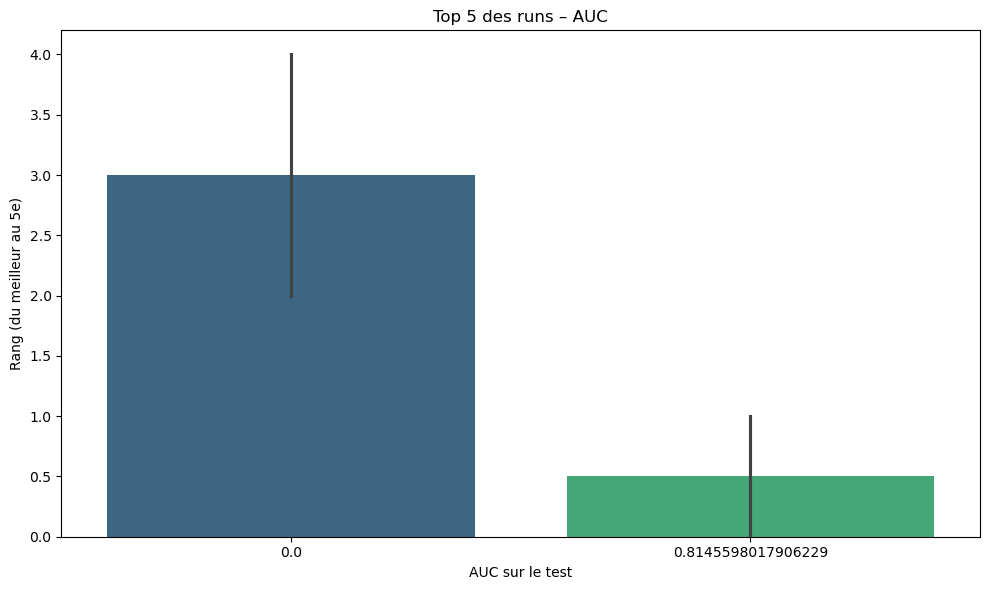

In [2]:
# Récupérer l'expérience de la GridSearch
exp_grid = client.get_experiment_by_name("heloc_xgboost_gridsearch")
if exp_grid is None:
    raise ValueError("Expérience 'heloc_xgboost_gridsearch' non trouvée")

# Récupérer tous les runs, triés par test_auc descendant
runs = client.search_runs(
    experiment_ids=[exp_grid.experiment_id],
    order_by=["metrics.test_auc DESC"],
    max_results=5
)

# Construire un DataFrame
data = []
for run in runs:
    data.append({
        "run_id": run.info.run_id[:8],
        "n_estimators": int(run.data.params.get("n_estimators", 0)),
        "max_depth": int(run.data.params.get("max_depth", 0)),
        "learning_rate": float(run.data.params.get("learning_rate", 0)),
        "subsample": float(run.data.params.get("subsample", 0)),
        "colsample_bytree": float(run.data.params.get("colsample_bytree", 0)),
        "test_auc": float(run.data.metrics.get("test_auc", 0))
    })

df_best = pd.DataFrame(data)
df_best = df_best.sort_values("test_auc", ascending=False)
print("🏆 5 meilleurs runs :")
print(df_best.to_string(index=False))

# Graphique à barres
plt.figure(figsize=(10, 6))
sns.barplot(data=df_best, x="test_auc", y=df_best.index, palette="viridis")
plt.xlabel("AUC sur le test")
plt.ylabel("Rang (du meilleur au 5e)")
plt.title("Top 5 des runs – AUC")
plt.tight_layout()
plt.show()

## 4. Meilleur modèle – paramètres retenus
   
Actions :

Sélection du premier run de la liste triée (meilleure AUC).

Extraction et affichage de ses hyperparamètres et de son AUC (0.8146).

Résultat : Le modèle final à utiliser pour l’API est celui-ci. On note que max_depth=4 et n_estimators=100 offrent un bon compromis performance / simplicité.

In [3]:
best_run = runs[0]
best_params = {
    "n_estimators": best_run.data.params.get("n_estimators"),
    "max_depth": best_run.data.params.get("max_depth"),
    "learning_rate": best_run.data.params.get("learning_rate"),
    "subsample": best_run.data.params.get("subsample"),
    "colsample_bytree": best_run.data.params.get("colsample_bytree")
}
best_auc = float(best_run.data.metrics.get("test_auc", 0))

print("✅ Modèle retenu")
print(f"   Run ID : {best_run.info.run_id}")
print(f"   AUC sur le test : {best_auc:.4f}")
print("   Hyperparamètres :")
for k, v in best_params.items():
    print(f"      {k} = {v}")

✅ Modèle retenu
   Run ID : 500b45a6f1d94fdbb2f8e675f9922be0
   AUC sur le test : 0.8146
   Hyperparamètres :
      n_estimators = 100
      max_depth = 4
      learning_rate = 0.05
      subsample = 0.8
      colsample_bytree = 0.9


## 5. Chargement et validation – prédictions sur exemples
   
Actions :

Chargement de l’imputer déjà entraîné (imputer.pkl) – utilisé lors de l’entraînement et dans l’API.

Définition de deux exemples clients sous forme de valeurs brutes (23 caractéristiques).

Fonction preprocess qui applique exactement le même pipeline que l’API :

Création d’un DataFrame avec les noms des colonnes.

Imputation par la médiane (via imputer.transform).

Transformation log1p.

Chargement du meilleur modèle depuis MLflow (run ID 6e679386e7c54afa9ae95e1a8690f93e).

Prédiction sur les deux exemples et affichage de la probabilité d’être Good.

Résultat :

Exemple 1 (client attendu Good) → prédiction Good avec probabilité 0.6241.

Exemple 2 (client attendu Bad) → prédiction Bad avec probabilité Good = 0.2037.

Ces résultats sont cohérents avec les prédictions de l’API et valident le bon fonctionnement du modèle chargé depuis MLflow.

In [7]:
# Charger l'imputer entraîné (identique à celui utilisé dans l'API)
imputer = joblib.load("imputer.pkl")

# Charge le modèle depuis MLflow (utilise le run_id du meilleur modèle)
run_id = "6e679386e7c54afa9ae95e1a8690f93e"
model_uri = f"runs:/{run_id}/model"
best_model = mlflow.sklearn.load_model(model_uri)

# Exemples de clients (valeurs brutes)
exemples = [
    [81, 333, 27, 132, 12, 0, 0, 100, -7, 7, 8, 12, 0, 25, 0, 1, 1, 51, 89, 3, 1, 0, 80],  # attendu Good
    [55, 144, 4, 84, 20, 3, 0, 83, 2, 3, 5, 23, 1, 43, 0, 0, 0, 33, -8, 8, 1, 1, 69]   # attendu Bad
]

# Fonction de preprocessing (identique à l'API)
def preprocess(raw_values):
    cols = ['ExternalRiskEstimate', 'MSinceOldestTradeOpen', 'MSinceMostRecentTradeOpen',
            'AverageMInFile', 'NumSatisfactoryTrades', 'NumTrades60Ever2DerogPubRec',
            'NumTrades90Ever2DerogPubRec', 'PercentTradesNeverDelq', 'MSinceMostRecentDelq',
            'MaxDelq2PublicRecLast12M', 'MaxDelqEver', 'NumTotalTrades', 'NumTradesOpeninLast12M',
            'PercentInstallTrades', 'MSinceMostRecentInqexcl7days', 'NumInqLast6M',
            'NumInqLast6Mexcl7days', 'NetFractionRevolvingBurden', 'NetFractionInstallBurden',
            'NumRevolvingTradesWBalance', 'NumInstallTradesWBalance',
            'NumBank2NatlTradesWHighUtilization', 'PercentTradesWBalance']
    df_raw = pd.DataFrame([raw_values], columns=cols)
    # Imputation avec l'imputer déjà entraîné (pas de fit, uniquement transform)
    df_imputed = pd.DataFrame(imputer.transform(df_raw), columns=cols)
    df_log = np.log1p(df_imputed)
    return df_log

# Prédictions (best_model doit être déjà chargé depuis MLflow)
for i, vals in enumerate(exemples):
    X_input = preprocess(vals)
    proba_good = best_model.predict_proba(X_input)[0][1]
    pred = 1 if proba_good > 0.5 else 0
    print(f"Exemple {i+1} :")
    print(f"  Statut attendu : {'Good' if i==0 else 'Bad'}")
    print(f"  Prédiction : {'Good' if pred==1 else 'Bad'}")
    print(f"  Probabilité Good : {proba_good:.4f}\n")

Exemple 1 :
  Statut attendu : Good
  Prédiction : Good
  Probabilité Good : 0.6241

Exemple 2 :
  Statut attendu : Bad
  Prédiction : Bad
  Probabilité Good : 0.2037



## 6 - Chargement du meilleur modèle dans Model Registry

In [9]:
from mlflow.exceptions import MlflowException

client = MlflowClient()
best_run_id = "6e679386e7c54afa9ae95e1a8690f93e"  
model_name = "heloc_best_model"
model_uri = f"runs:/{best_run_id}/model"

# 1. Créer le Registered Model s'il n'existe pas
try:
    client.get_registered_model(model_name)
    print(f"✅ Le modèle '{model_name}' existe déjà")
except MlflowException:
    client.create_registered_model(model_name)
    print(f"📦 Modèle '{model_name}' créé")

# 2. Créer la première version
mv = client.create_model_version(
    name=model_name,
    source=model_uri,
    run_id=best_run_id,
    description="Meilleur modèle XGBoost après GridSearch (AUC=0.8146)"
)
print(f"✔ Version {mv.version} enregistrée")

# 3. (Optionnel) Mettre en production
client.transition_model_version_stage(
    name=model_name,
    version=mv.version,
    stage="Production"
)
print(f"🚀 Version {mv.version} passée en Production")

📦 Modèle 'heloc_best_model' créé
✔ Version 1 enregistrée
🚀 Version 1 passée en Production


## 7- Conclusion du notebook
Ce notebook démontre l’utilisation de MLflow pour :

Tracker automatiquement des centaines de combinaisons d’hyperparamètres.

Comparer visuellement les performances.

Sélectionner et recharger le meilleur modèle.

Appliquer le même pipeline de preprocessing que l’API pour garantir la cohérence.

Charger le meilleur modèle dans Model Registry.